# Fund Performance Analytics

## Day 4 – Mutual Fund Performance Analysis

### Objectives
- Compute Daily Returns
- Calculate CAGR (1Y, 3Y, 5Y)
- Calculate Sharpe Ratio
- Calculate Sortino Ratio
- Calculate Alpha & Beta
- Analyze Maximum Drawdown
- Generate Fund Scorecard
- Compare Top Funds Against Benchmarks


# 1. Import Required Libraries

This section imports all required Python libraries for data manipulation,
statistical analysis, visualization, and performance metric calculations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

# 2. Load Processed NAV Dataset

The cleaned NAV dataset generated during previous stages of the project
is loaded for performance analysis.

In [4]:
nav = pd.read_csv("02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


# 3. Dataset Overview

Understanding the dataset structure before calculating fund performance
metrics.

In [5]:
print("Shape:", nav.shape)

nav.info()

Shape: (46000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [6]:
nav.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


### Observation

- Dataset contains historical NAV records for all mutual fund schemes.
- Date column has been converted to datetime format.
- Data appears ready for return calculations.

# 4. Daily Return Calculation

Daily return measures the percentage change in Net Asset Value (NAV)
from one trading day to the next.

Formula:

Daily Return = (NAVₜ / NAVₜ₋₁) − 1

The calculation is performed separately for each mutual fund scheme
using its AMFI code.

## View Daily Returns

The newly created `daily_return` column is inspected to verify that
returns have been calculated correctly for each mutual fund scheme.

In [9]:
nav.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


## Daily Return Summary Statistics

Summary statistics are generated to understand the overall behavior
of daily returns across all funds.

In [11]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [20]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

## Daily Return Summary Statistics

Summary statistics are generated to understand the overall behavior
of daily returns across all mutual funds.

In [21]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [13]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [15]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Daily Return Distribution

A histogram is used to visualize the distribution of daily returns across all mutual funds. This helps identify the overall return pattern and detect potential outliers.

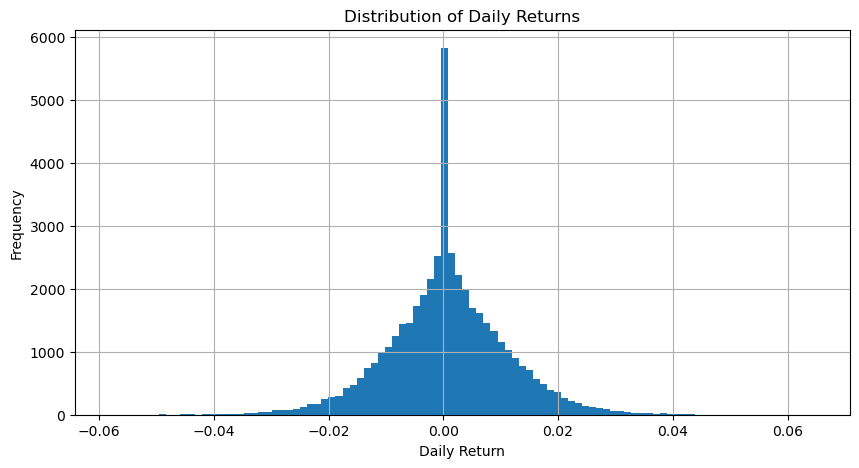

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Most daily returns are concentrated around zero.
- Positive and negative return movements appear balanced.
- No major anomalies were observed in the return distribution.
- The dataset is suitable for further performance analytics.

# 5. Compound Annual Growth Rate (CAGR)

Compound Annual Growth Rate (CAGR) measures the annualized rate of
growth of a mutual fund over a specified investment horizon.

Formula:

CAGR = (NAV_end / NAV_start)^(1/n) − 1

Where:

- NAV_end = Ending NAV
- NAV_start = Starting NAV
- n = Number of Years

The following periods are evaluated:

- 1 Year
- 3 Years
- 5 Years

In [24]:
def calculate_cagr(df, years):

    end_date = df["date"].max()

    start_date = (
        end_date -
        pd.DateOffset(years=years)
    )

    subset = df[
        df["date"] >= start_date
    ].sort_values("date")

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]
    end_nav = subset.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [25]:
cagr_results = []

for fund, group in nav.groupby("amfi_code"):

    cagr_results.append({

        "amfi_code": fund,

        "cagr_1y":
            calculate_cagr(group, 1),

        "cagr_3y":
            calculate_cagr(group, 3),

        "cagr_5y":
            calculate_cagr(group, 5)

    })

cagr_df = pd.DataFrame(
    cagr_results
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


## CAGR Comparison Table

The CAGR values for all funds are consolidated into a comparison table
to facilitate performance evaluation across different investment horizons.

In [26]:
cagr_df = cagr_df.sort_values(
    "cagr_3y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,0.222611,0.351118,0.244453
34,148567,0.203607,0.340009,0.267993
24,120504,0.130643,0.324874,0.202340
2,100033,0.532324,0.324425,0.260741
25,120505,0.296047,0.317775,0.283768
19,119551,0.604373,0.304565,0.223849
30,120843,0.266571,0.295828,0.267425
36,148569,0.397518,0.291789,0.276299
3,101206,0.479241,0.289677,0.204427
39,149324,0.651387,0.270004,0.279174


In [27]:
cagr_df.style.format({

    "cagr_1y": "{:.2%}",
    "cagr_3y": "{:.2%}",
    "cagr_5y": "{:.2%}"

})

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,22.26%,35.11%,24.45%
34,148567,20.36%,34.00%,26.80%
24,120504,13.06%,32.49%,20.23%
2,100033,53.23%,32.44%,26.07%
25,120505,29.60%,31.78%,28.38%
19,119551,60.44%,30.46%,22.38%
30,120843,26.66%,29.58%,26.74%
36,148569,39.75%,29.18%,27.63%
3,101206,47.92%,28.97%,20.44%
39,149324,65.14%,27.00%,27.92%


### Observation

- Funds with higher CAGR values have delivered stronger long-term growth.
- The 3-Year CAGR is used as a key performance metric in the Fund Scorecard.
- CAGR provides a standardized basis for comparing funds with different NAV trajectories.

In [29]:
cagr_df.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

print(
    "CAGR comparison table exported successfully."
)

CAGR comparison table exported successfully.


# 6. Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted performance of a mutual fund.

It evaluates how much excess return is generated for each unit of risk taken.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate
- σ = Standard Deviation of Daily Returns
- 252 = Approximate Trading Days in a Year

Assumption:

Risk-Free Rate (Rf) = 6.5% per annum (RBI Repo Rate Proxy)

In [30]:
cagr_df.shape
cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,0.222611,0.351118,0.244453
34,148567,0.203607,0.340009,0.267993
24,120504,0.130643,0.324874,0.202340
2,100033,0.532324,0.324425,0.260741
25,120505,0.296047,0.317775,0.283768


In [31]:
RF = 0.065

daily_rf = RF / 252

print("Annual Risk-Free Rate:", RF)
print("Daily Risk-Free Rate:", daily_rf)

Annual Risk-Free Rate: 0.065
Daily Risk-Free Rate: 0.00025793650793650796


## Sharpe Ratio Calculation

The Sharpe Ratio is calculated separately for each mutual fund scheme
using daily returns.

In [33]:
sharpe_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    sharpe_ratio = (
        (returns.mean() - daily_rf)
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


## Sharpe Ratio Ranking

Funds are ranked based on their Sharpe Ratio.

Higher Sharpe Ratios indicate superior risk-adjusted performance.

In [34]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df["sharpe_rank"] = range(
    1,
    len(sharpe_df)+1
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1
30,120843,1.306744,2
36,148569,1.234930,3
19,119551,1.208267,4
25,120505,1.180101,5
38,149323,1.132122,6
2,100033,1.093699,7
9,118632,1.081659,8
3,101206,1.027213,9
24,120504,1.026524,10


In [35]:
sharpe_df.style.format({
    "sharpe_ratio": "{:.4f}"
})

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.4483,1
30,120843,1.3067,2
36,148569,1.2349,3
19,119551,1.2083,4
25,120505,1.1801,5
38,149323,1.1321,6
2,100033,1.0937,7
9,118632,1.0817,8
3,101206,1.0272,9
24,120504,1.0265,10


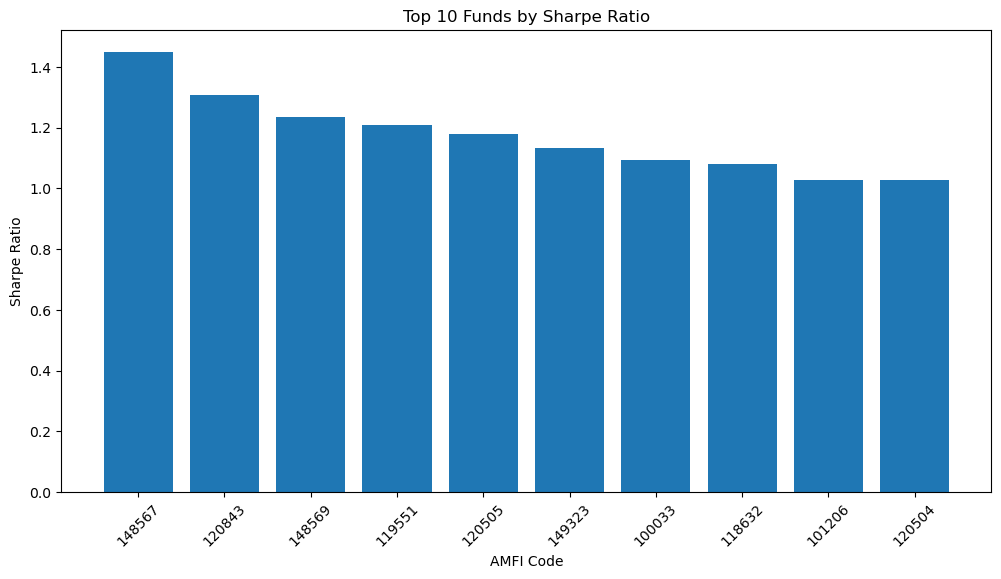

In [36]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

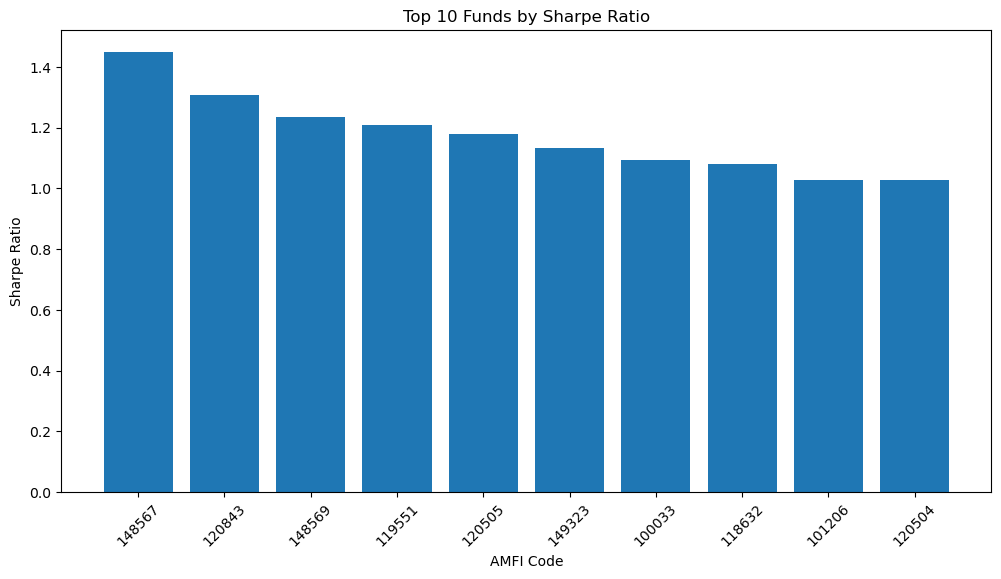

In [37]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/top10_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Funds with higher Sharpe Ratios delivered stronger returns relative to their volatility.
- A higher Sharpe Ratio indicates more efficient risk-adjusted performance.
- Sharpe Ratio is one of the key components of the final Fund Scorecard.

In [39]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio results exported successfully.")

Sharpe Ratio results exported successfully.


In [40]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio results exported successfully.")

Sharpe Ratio results exported successfully.


# 7. Sortino Ratio

The Sortino Ratio measures risk-adjusted performance while considering
only downside volatility.

Unlike the Sharpe Ratio, it does not penalize positive return volatility.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation × √252

In [41]:
sortino_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        continue

    downside_std = downside_returns.std()

    sortino_ratio = (
        (returns.mean() - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()


,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [42]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df["sortino_rank"] = range(
    1,
    len(sortino_df)+1
)

sortino_df.head(10)

,amfi_code,sortino_ratio,sortino_rank
34,148567,2.385644,1
30,120843,2.364320,2
36,148569,2.146914,3
19,119551,2.140267,4
25,120505,2.029353,5
38,149323,1.875101,6
9,118632,1.850133,7
2,100033,1.829134,8
24,120504,1.805294,9
3,101206,1.799563,10


In [43]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [44]:
benchmark = pd.read_csv(
    "10_benchmark_indices_clean.csv"
)

benchmark.columns
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [45]:
fund_master = pd.read_csv(
    "01_fund_master_clean.csv"
)

fund_master.columns
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [46]:
benchmark.columns
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
fund_master.columns
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


# 8. Alpha and Beta Analysis

Alpha measures the excess return generated by a fund relative to its benchmark.

Beta measures the sensitivity of a fund's returns to benchmark movements.

Benchmark Used:
- NIFTY100

Method:
- Ordinary Least Squares (OLS) Regression
- scipy.stats.linregress

Formula:

Alpha = Intercept × 252

Beta = Regression Slope

In [48]:
from scipy.stats import linregress

In [49]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [50]:
alpha_beta_results = []

for fund, group in nav.groupby("amfi_code"):

    fund_returns = group[
        ["date", "daily_return"]
    ].copy()

    merged = pd.merge(
        fund_returns,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({

        "amfi_code": fund,

        "alpha":
            intercept * 252,

        "beta":
            slope

    })

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [51]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported")

alpha_beta.csv exported


# 9. Maximum Drawdown

Maximum Drawdown represents the largest decline from a historical peak NAV.

Formula:

Drawdown = NAV / Running Maximum NAV − 1

The most negative value represents the Maximum Drawdown.

In [53]:
drawdown_results = []

for fund, group in nav.groupby("amfi_code"):

    temp = group.copy()

    temp = temp.sort_values("date")

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    trough_idx = temp["drawdown"].idxmin()

    trough_date = temp.loc[
        trough_idx,
        "date"
    ]

    drawdown_results.append({

        "amfi_code": fund,

        "max_drawdown":
            max_dd,

        "trough_date":
            trough_date

    })

drawdown_df = pd.DataFrame(
    drawdown_results
)

drawdown_df.head()

,amfi_code,max_drawdown,trough_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


# 10. Fund Scorecard

A composite score is generated using:

- 30% 3-Year CAGR Rank
- 25% Sharpe Ratio Rank
- 20% Alpha Rank
- 15% Expense Ratio Rank (Inverse)
- 10% Maximum Drawdown Rank (Inverse)

The final score is scaled to a range of 0–100.

In [54]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df[
            ["amfi_code",
             "sharpe_ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df[
            ["amfi_code",
             "max_drawdown"]
        ],
        on="amfi_code"
    )
    .merge(
        fund_master[
            ["amfi_code",
             "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.38
1,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,1.46
2,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,0.80
3,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38
4,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36


In [55]:
scorecard["return_rank"] = (
    scorecard["cagr_3y"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [56]:
scorecard["raw_score"] = (

    0.30 * scorecard["return_rank"]

    +

    0.25 * scorecard["sharpe_rank"]

    +

    0.20 * scorecard["alpha_rank"]

    +

    0.15 * scorecard["expense_rank"]

    +

    0.10 * scorecard["dd_rank"]

)


In [57]:
scorecard["fund_score"] = (

    100 *

    (

        scorecard["raw_score"].max()

        -

        scorecard["raw_score"]

    )

    /

    (

        scorecard["raw_score"].max()

        -

        scorecard["raw_score"].min()

    )

)

scorecard["overall_rank"] = (
    scorecard["fund_score"]
    .rank(
        ascending=False
    )
)

scorecard = scorecard.sort_values(
    "overall_rank"
)

scorecard.head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,raw_score,fund_score,overall_rank
1,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.500,100.000000,1.0
4,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,94.439618,2.0
6,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.200,94.092094,3.0
3,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.700,92.354474,4.0
2,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.000,91.311903,5.0
0,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,87.141616,6.0
5,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,11.075,84.100782,7.0
7,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,11.525,82.536924,8.0
8,101206,0.479241,0.289677,0.204427,1.027213,0.213998,0.021086,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,13.725,74.891399,9.0
11,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,14.050,73.761946,10.0


In [58]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv exported")

fund_scorecard.csv exported


In [59]:
top5 = (
    scorecard
    .head(5)
    ["amfi_code"]
    .tolist()
)

top5

[148567, 120505, 120843, 100033, 120504]

In [60]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

# 11. Benchmark Comparison

The top five ranked mutual funds are compared against:

- NIFTY50
- NIFTY100

Comparison Period:
- Last 3 Years

All series are rebased to 100 to enable direct comparison of cumulative performance.

Tracking Error is also calculated to measure deviation from benchmark returns.

In [62]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [63]:
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["normalized"] = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"]
    /
    nifty100["close_value"].iloc[0]
) * 100


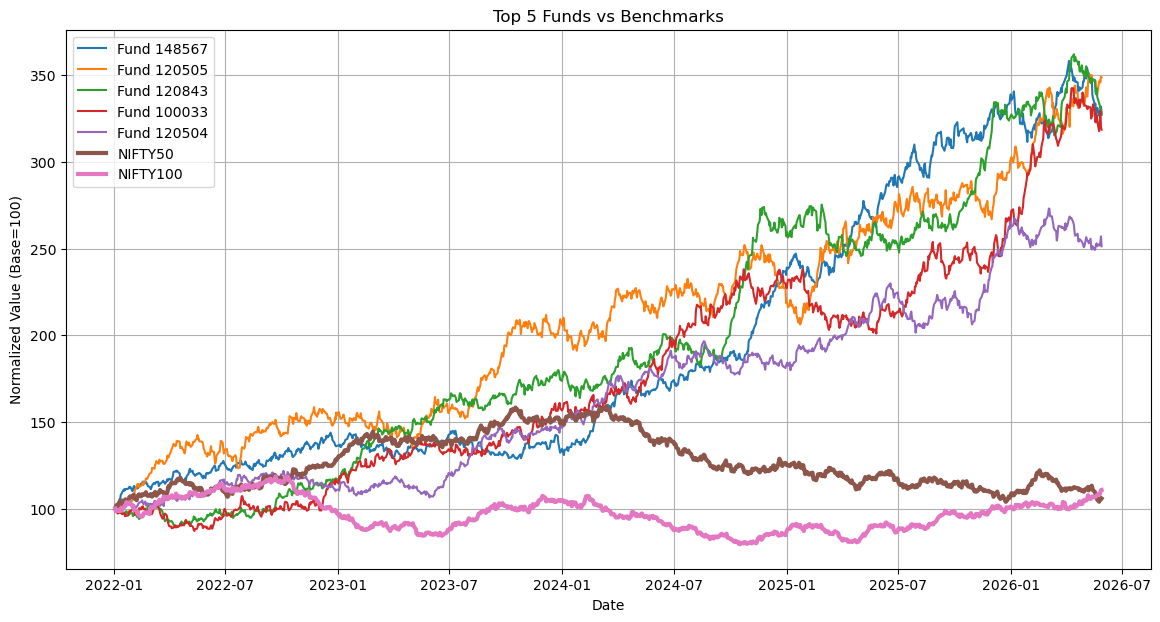

In [65]:
plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    label="NIFTY100",
    linewidth=3
)

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base=100)")

plt.legend()

plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Tracking Error

Tracking Error measures the annualized volatility of the difference between
fund returns and benchmark returns.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [66]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [67]:
tracking_error_results = []

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (

        (
            merged["daily_return"]

            -

            merged["benchmark_return"]

        ).std()

        * np.sqrt(252)

    )

    tracking_error_results.append({

        "amfi_code": fund,

        "tracking_error":
            tracking_error

    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,100033,0.228699
4,120504,0.191587


In [68]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

In [73]:
print("All deliverables exported successfully.")

All deliverables exported successfully.


# Conclusion

This notebook evaluated mutual fund performance using return-based,
risk-adjusted, benchmark-relative, and downside-risk metrics.

Key analyses completed:

- Daily Return Calculation
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta Analysis
- Maximum Drawdown Analysis
- Composite Fund Scorecard
- Benchmark Comparison
- Tracking Error Analysis

The generated outputs provide a comprehensive framework for evaluating
mutual fund performance and identifying the strongest performing schemes.